In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv(r"car_purchasing.csv", encoding='latin')
data.head()

,customer name,customer e-mail,country,gender,age,annual Salary,credit card debt,net worth,car purchase amount
0,Martina Avila,cubilia.Curae.Phasellus@quisaccumsanconvallis.edu,Bulgaria,0,41.851720,62812.09301,11609.380910,238961.2505,35321.45877
1,Harlan Barnes,eu.dolor@diam.co.uk,Belize,0,40.870623,66646.89292,9572.957136,530973.9078,45115.52566
2,Naomi Rodriquez,vulputate.mauris.sagittis@ametconsectetueradip...,Algeria,1,43.152897,53798.55112,11160.355060,638467.1773,42925.70921
3,Jade Cunningham,malesuada@dignissim.com,Cook Islands,1,58.271369,79370.03798,14426.164850,548599.0524,67422.36313
4,Cedric Leach,felis.ullamcorper.viverra@egetmollislectus.net,Brazil,1,57.313749,59729.15130,5358.712177,560304.0671,55915.46248


In [5]:
data.drop(columns=['customer name','customer e-mail'], inplace=True)

In [6]:
data.head(2)

,country,gender,age,annual Salary,credit card debt,net worth,car purchase amount
0,Bulgaria,0,41.851720,62812.09301,11609.380910,238961.2505,35321.45877
1,Belize,0,40.870623,66646.89292,9572.957136,530973.9078,45115.52566


In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   country              500 non-null    str    
 1   gender               500 non-null    int64  
 2   age                  500 non-null    float64
 3   annual Salary        500 non-null    float64
 4   credit card debt     500 non-null    float64
 5   net worth            500 non-null    float64
 6   car purchase amount  500 non-null    float64
dtypes: float64(5), int64(1), str(1)
memory usage: 32.5 KB


In [8]:
# convert float values to integer
for col in data.columns:
    if data[col].dtypes == 'float64':
        data[col] = data[col].astype(int)

In [9]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   country              500 non-null    str  
 1   gender               500 non-null    int64
 2   age                  500 non-null    int64
 3   annual Salary        500 non-null    int64
 4   credit card debt     500 non-null    int64
 5   net worth            500 non-null    int64
 6   car purchase amount  500 non-null    int64
dtypes: int64(6), str(1)
memory usage: 32.5 KB


In [10]:
data.head()

,country,gender,age,annual Salary,credit card debt,net worth,car purchase amount
0,Bulgaria,0,41,62812,11609,238961,35321
1,Belize,0,40,66646,9572,530973,45115
2,Algeria,1,43,53798,11160,638467,42925
3,Cook Islands,1,58,79370,14426,548599,67422
4,Brazil,1,57,59729,5358,560304,55915


In [11]:
# check null value
data.isna().sum()

country                0
gender                 0
age                    0
annual Salary          0
credit card debt       0
net worth              0
car purchase amount    0
dtype: int64

In [12]:
# check duplicated 
data.duplicated().sum()

np.int64(0)

# EDA

In [13]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   country              500 non-null    str  
 1   gender               500 non-null    int64
 2   age                  500 non-null    int64
 3   annual Salary        500 non-null    int64
 4   credit card debt     500 non-null    int64
 5   net worth            500 non-null    int64
 6   car purchase amount  500 non-null    int64
dtypes: int64(6), str(1)
memory usage: 32.5 KB


In [22]:
data.country.value_counts()

country
Bolivia                                         6
Israel                                          6
Mauritania                                      6
Algeria                                         5
Armenia                                         5
                                               ..
Ukraine                                         1
New Zealand                                     1
Saint Helena, Ascension and Tristan da Cunha    1
Malaysia                                        1
marlal                                          1
Name: count, Length: 211, dtype: int64

In [25]:
data.country.value_counts().sort_values(ascending=False).head(10)

country
Bolivia       6
Israel        6
Mauritania    6
Algeria       5
Armenia       5
Greenland     5
Iraq          5
Bhutan        5
Samoa         5
Laos          5
Name: count, dtype: int64

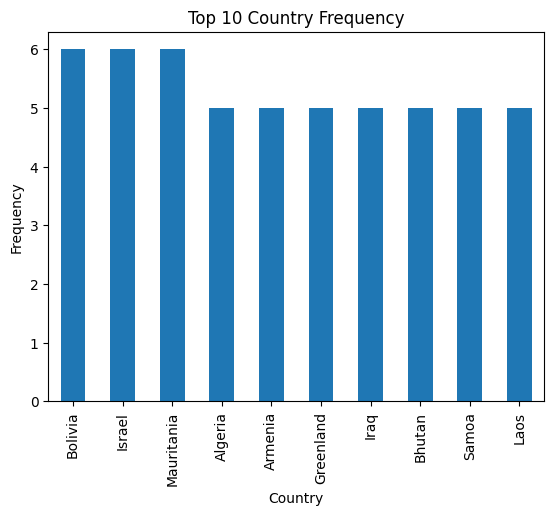

In [31]:
# bar plot
data['country'].value_counts().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 Country Frequency")
plt.ylabel("Frequency")
plt.xlabel("Country")
plt.show()

In [32]:
data.head(2)

,country,gender,age,annual Salary,credit card debt,net worth,car purchase amount
0,Bulgaria,0,41,62812,11609,238961,35321
1,Belize,0,40,66646,9572,530973,45115


In [34]:
data.gender.value_counts()

gender
1    253
0    247
Name: count, dtype: int64

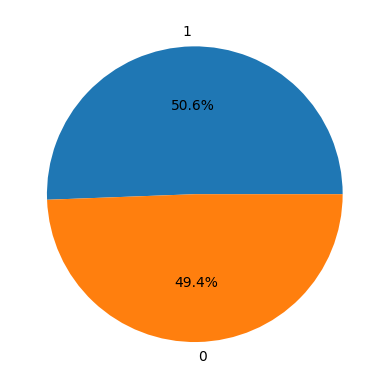

In [39]:
data.gender.value_counts().plot(kind='pie', autopct='%1.1f%%', label='gender')
plt.show()
# 1 - male , 0 - female
# there are almost same number of male and females

<Axes: xlabel='annual Salary', ylabel='Count'>

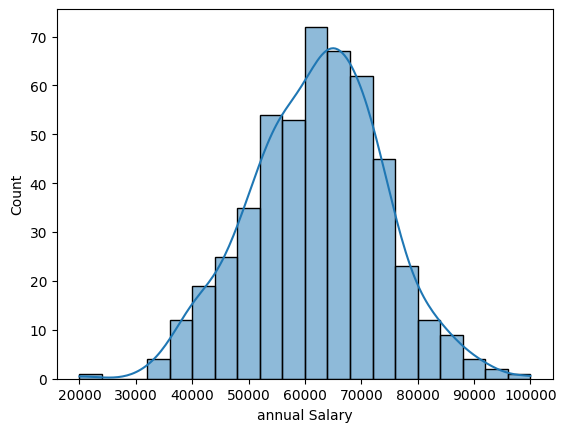

In [43]:
sns.histplot(data['annual Salary'], bins=20, kde=True)

In [45]:
data['annual Salary'].describe()

count       500.000000
mean      62126.748000
std       11703.393848
min       20000.000000
25%       54391.750000
50%       62915.000000
75%       70117.250000
max      100000.000000
Name: annual Salary, dtype: float64

<Axes: >

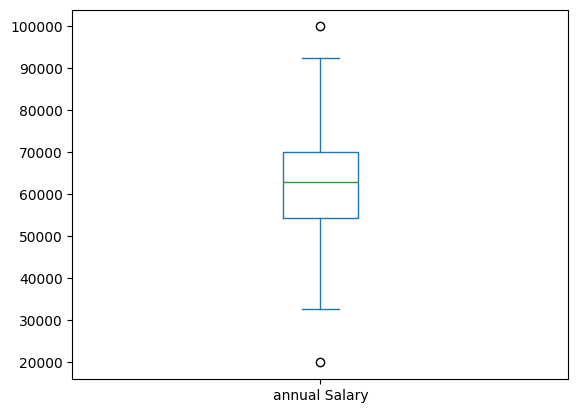

In [46]:
data['annual Salary'].plot(kind='box')

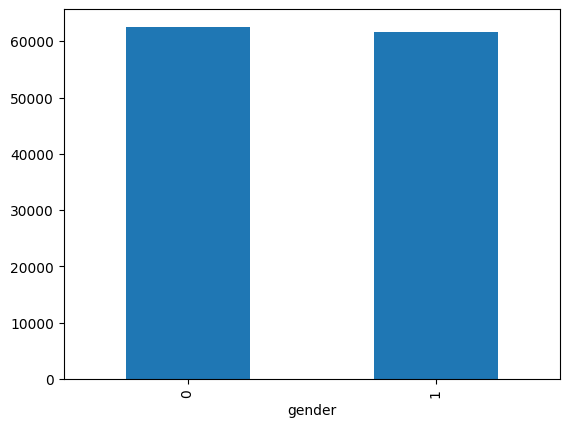

In [47]:
# gender vs annual salary
data.groupby('gender')['annual Salary'].mean().plot(kind='bar')
plt.show()

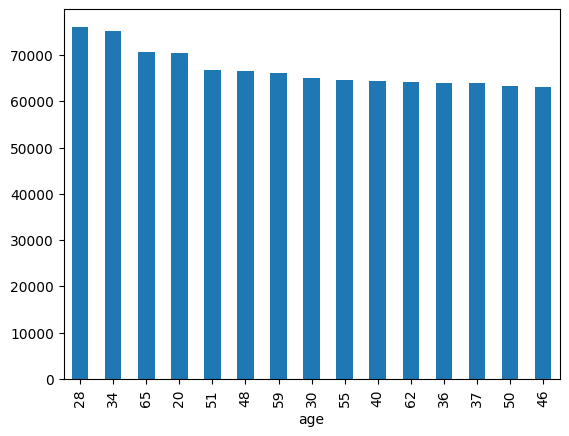

In [53]:
# age vs annual salary (15 age with highest salary)
data.groupby('age')['annual Salary'].mean().sort_values(ascending=False).head(15).plot(kind='bar')
plt.show()

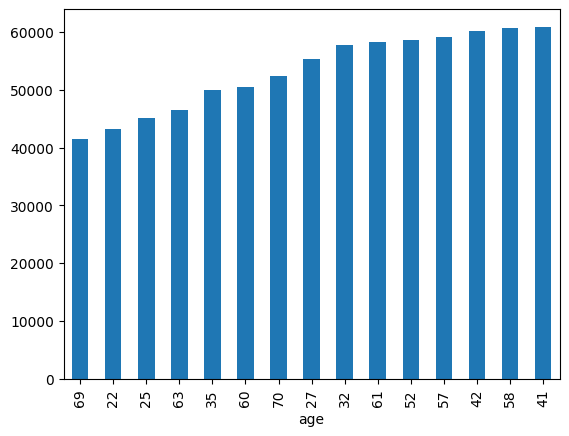

In [56]:
# age vs annual salary (15 ages that earns less)
data.groupby('age')['annual Salary'].mean().sort_values().head(15).plot(kind='bar')
plt.show()

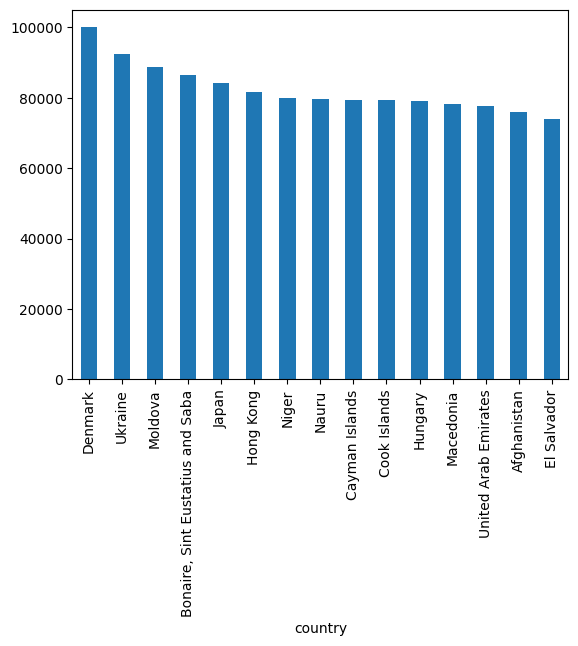

In [62]:
# country vs annual salary (15 country  with highest salary)
data.groupby('country')['annual Salary'].mean().sort_values(ascending=False).head(15).plot(kind='bar')
plt.show()

In [63]:
data.head()

,country,gender,age,annual Salary,credit card debt,net worth,car purchase amount
0,Bulgaria,0,41,62812,11609,238961,35321
1,Belize,0,40,66646,9572,530973,45115
2,Algeria,1,43,53798,11160,638467,42925
3,Cook Islands,1,58,79370,14426,548599,67422
4,Brazil,1,57,59729,5358,560304,55915


<Axes: xlabel='gender'>

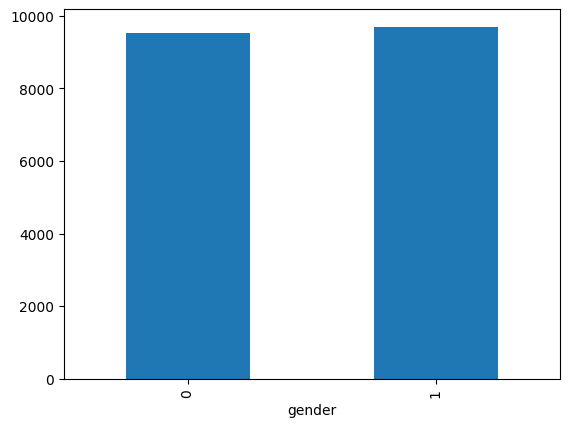

In [65]:
# gender vs credit card debt
data.groupby('gender')['credit card debt'].mean().plot(kind='bar')

<Axes: xlabel='annual Salary', ylabel='credit card debt'>

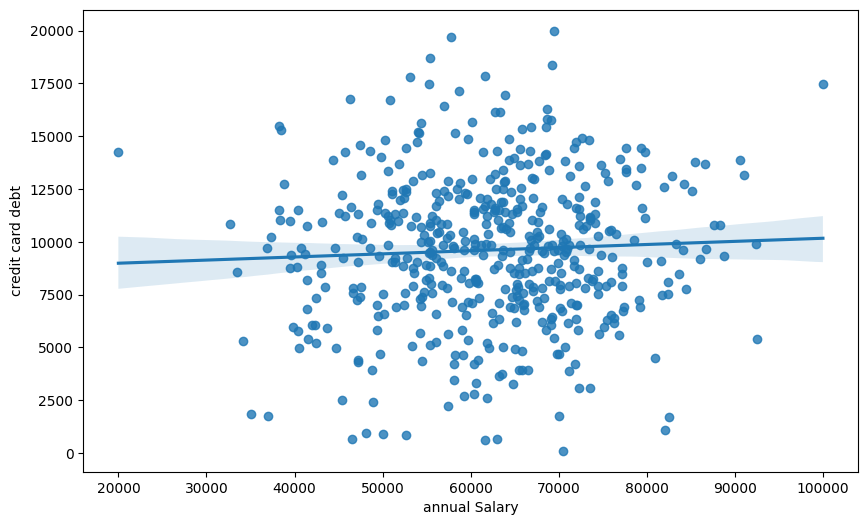

In [68]:
# annual Salary vs credit card debt
plt.figure(figsize=(10,6))
sns.regplot(x=data['annual Salary'], y=data['credit card debt'])

<Axes: xlabel='annual Salary', ylabel='net worth'>

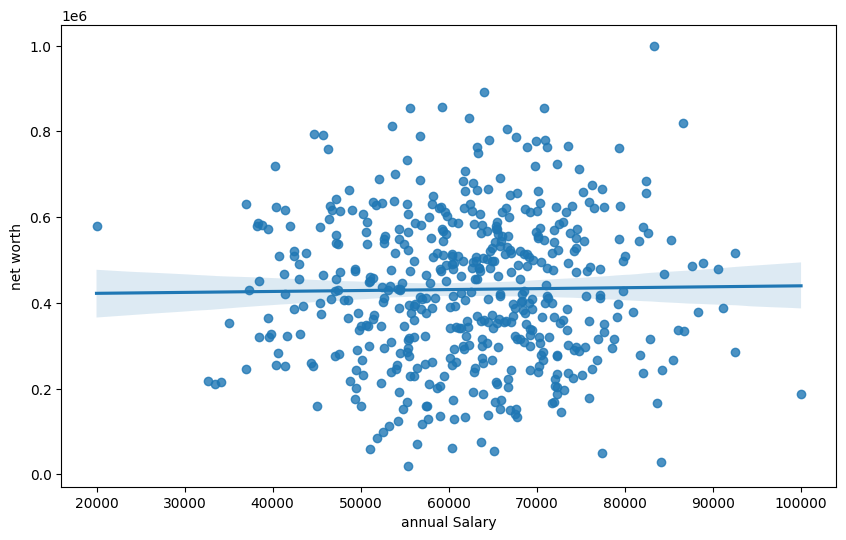

In [70]:
# annual salary vs net worth
plt.figure(figsize=(10,6))
sns.regplot(x=data['annual Salary'], y=data['net worth'])

In [71]:
# car purchase amount
data['car purchase amount'].describe()

count      500.000000
mean     44209.292000
std      10773.182684
min       9000.000000
25%      37629.500000
50%      43997.500000
75%      51254.500000
max      80000.000000
Name: car purchase amount, dtype: float64

<Axes: xlabel='gender'>

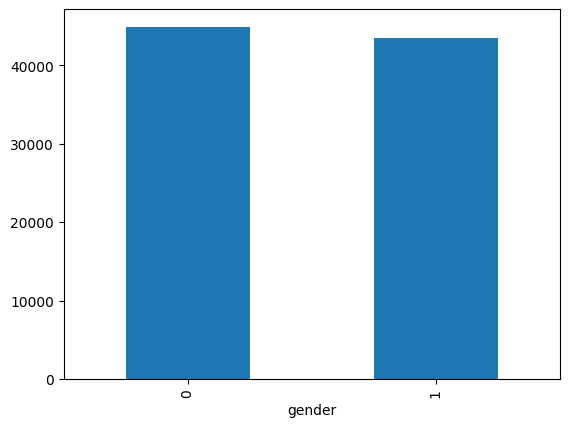

In [73]:
# gender vs car purchase amount
data.groupby('gender')['car purchase amount'].mean().plot(kind='bar')

<Axes: xlabel='annual Salary', ylabel='car purchase amount'>

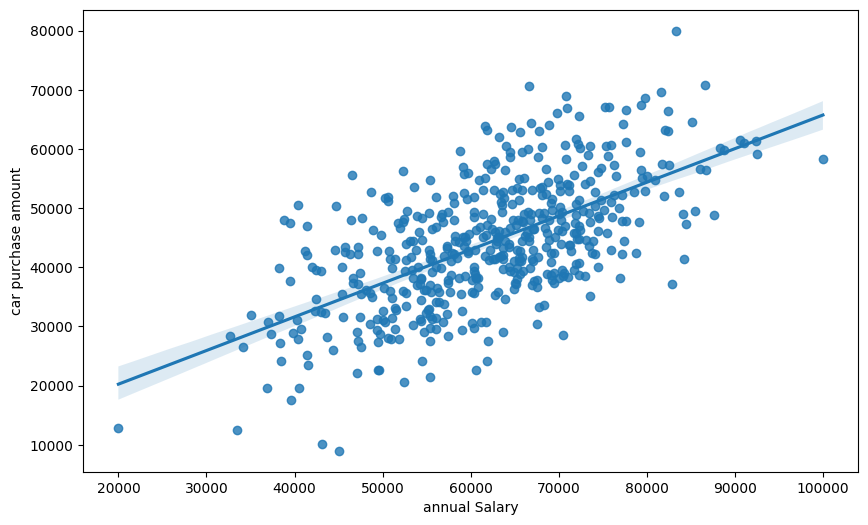

In [75]:
# car purchase amount vs annual salary
plt.figure(figsize=(10,6))
sns.regplot(x=data['annual Salary'], y=data['car purchase amount'])

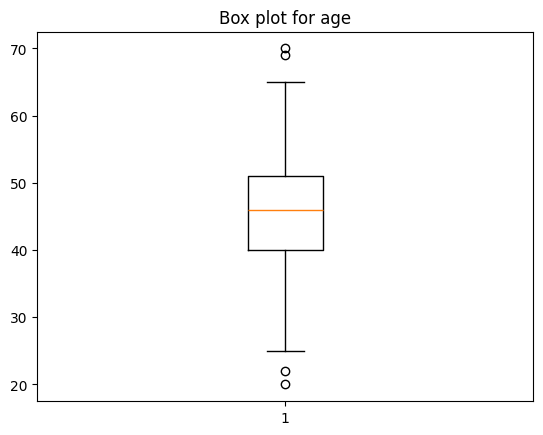

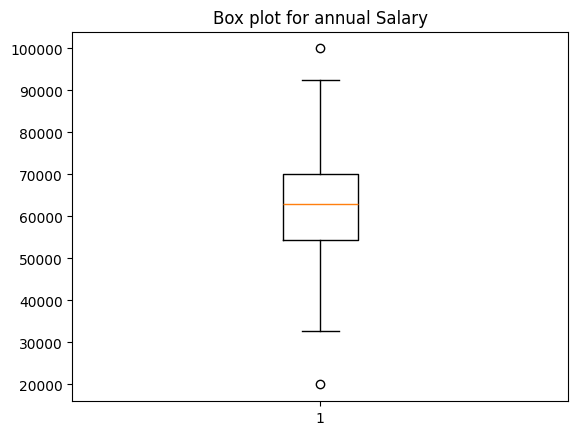

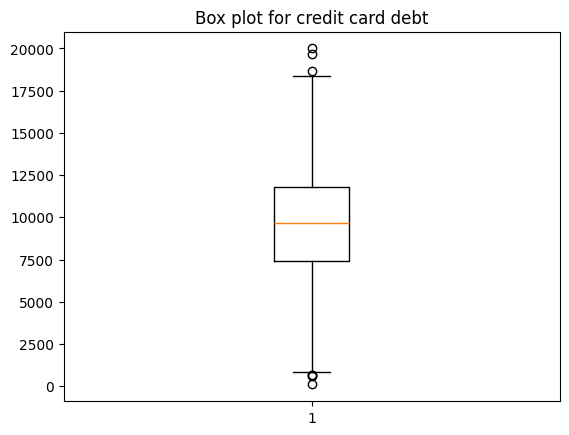

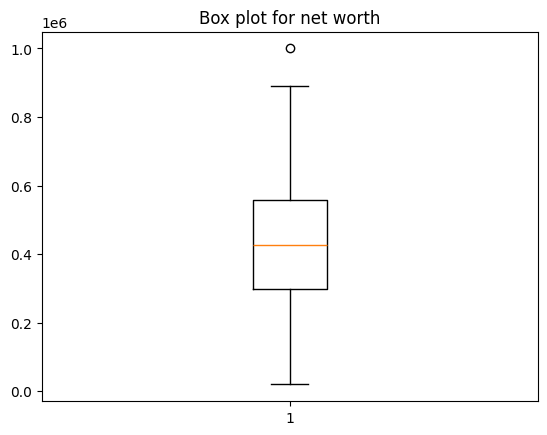

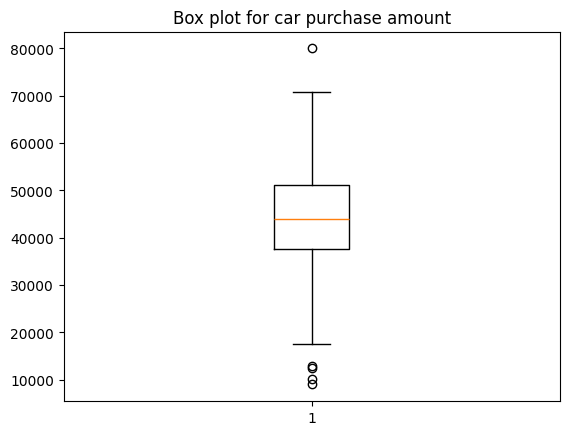

In [78]:
# BOX PLOTS
columns_to_plot = ['age', 'annual Salary', 'credit card debt', 'net worth', 'car purchase amount']

# plot box plots seperately for each column
for col in columns_to_plot:
    plt.boxplot(data[col])
    plt.title(f'Box plot for {col}')
    plt.show()

# Outliers Removal

In [79]:
# there are few outliers 

In [80]:
data.shape

(500, 7)

In [110]:
def remove_outliers(data):
    for col in data.select_dtypes(include='number').columns:
        q1 = data[col].quantile(0.25)
        q3 = data[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        data = data[(data[col] >= lower_bound) & (data[col]<=upper_bound)]
        
        

In [111]:
remove_outliers(data)

In [112]:
data.shape

(493, 7)

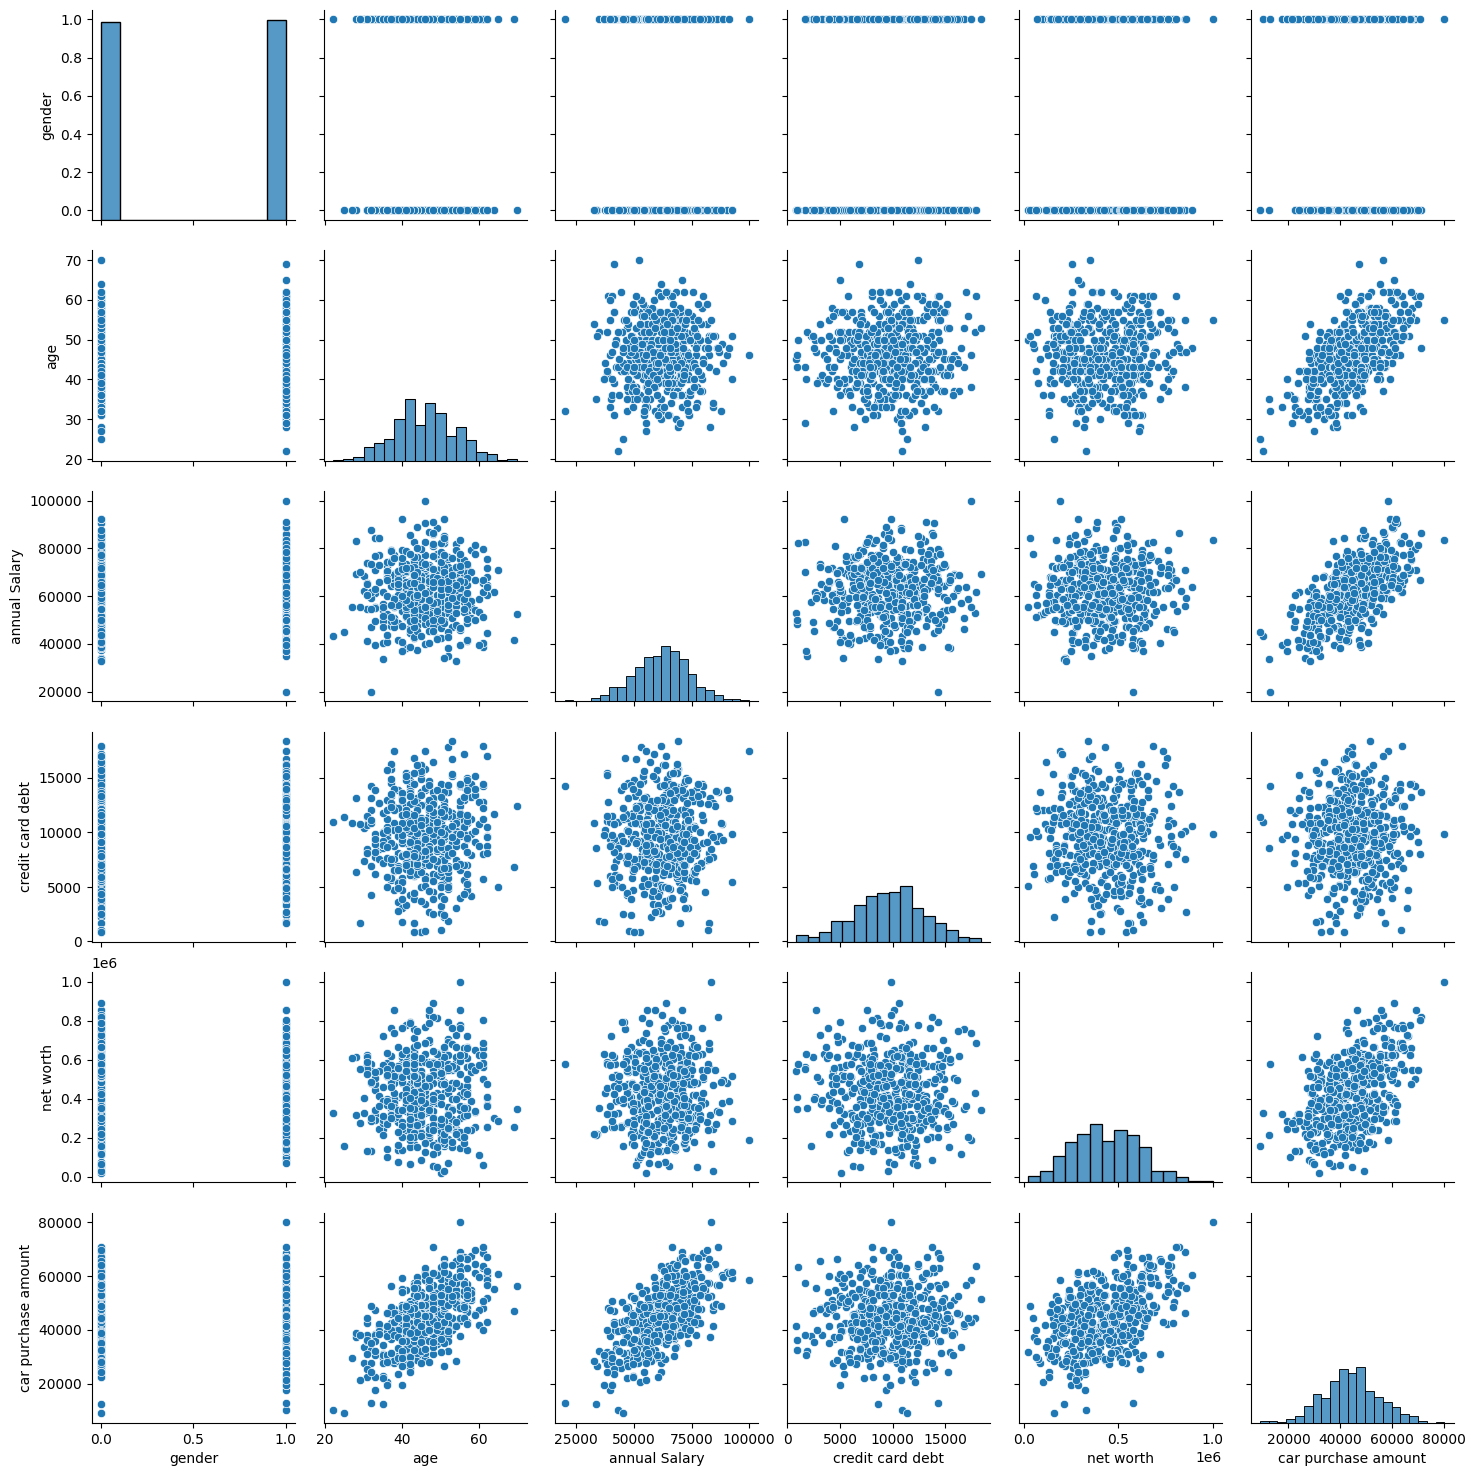

In [113]:
# pari plot
sns.pairplot(data)

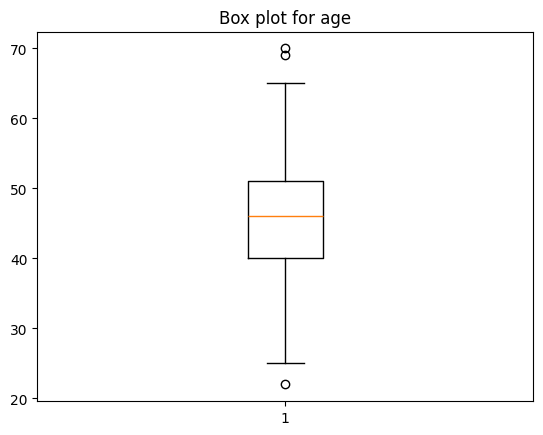

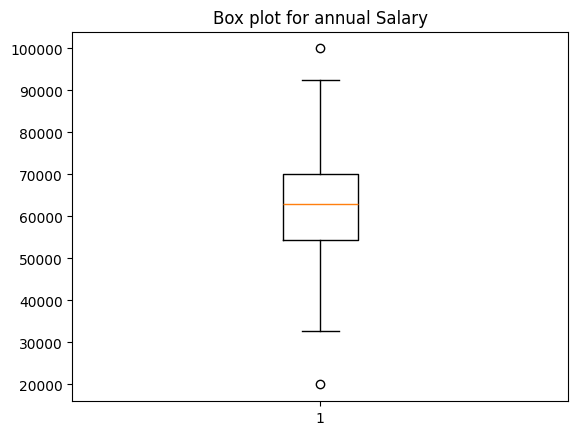

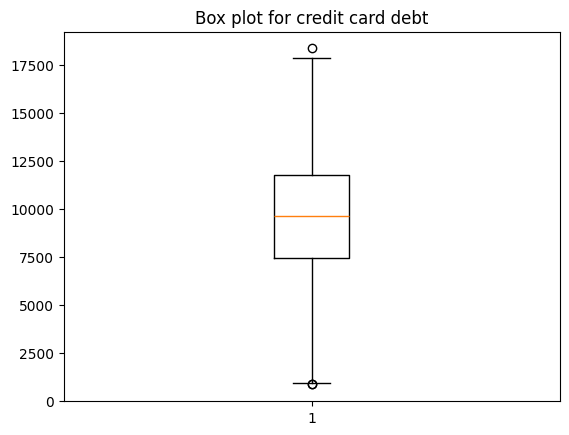

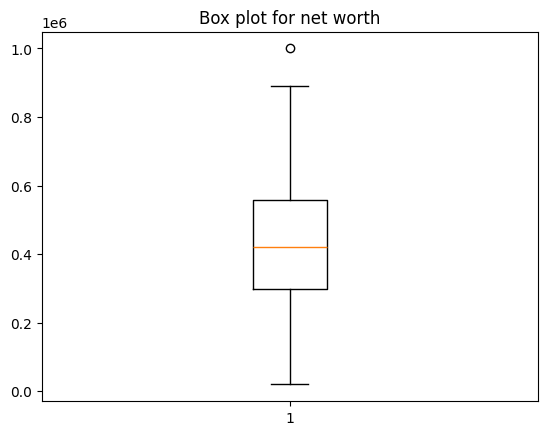

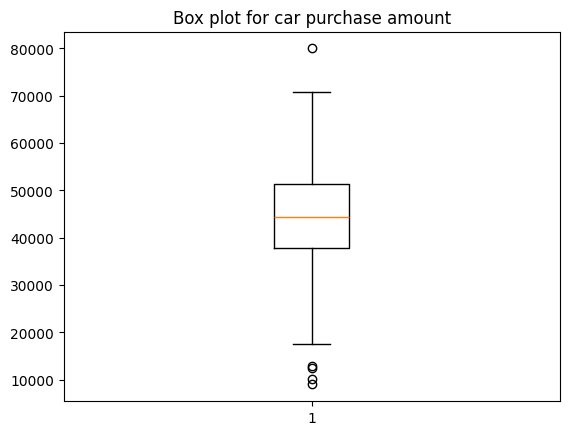

In [114]:
# BOX PLOTS
columns_to_plot = ['age', 'annual Salary', 'credit card debt', 'net worth', 'car purchase amount']

# plot box plots seperately for each column
for col in columns_to_plot:
    plt.boxplot(data[col])
    plt.title(f'Box plot for {col}')
    plt.show()

In [115]:
data.shape

(493, 7)

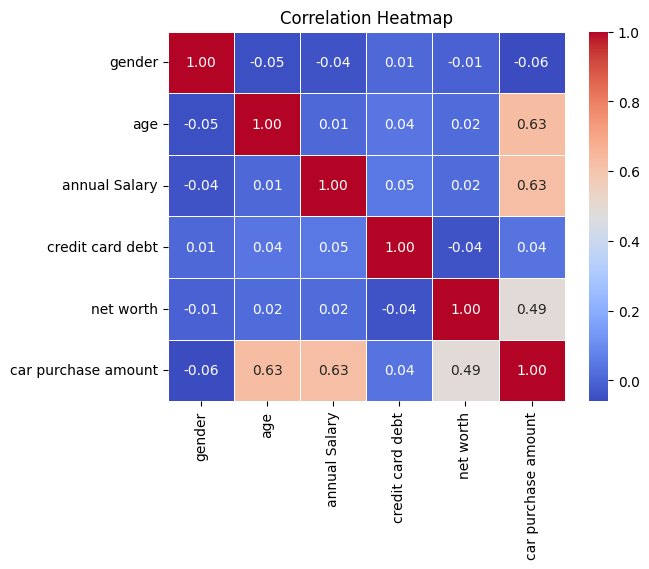

In [119]:
# heatmap
num_cols = data.select_dtypes('int','float')
heatmap = sns.heatmap(num_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidth=.5)
heatmap.set_title("Correlation Heatmap")
plt.show()

# MOdel building and Evaluation

In [121]:
# Encoding
data.country

0          Bulgaria
1            Belize
2           Algeria
3      Cook Islands
4            Brazil
           ...     
495           Nepal
496        Zimbabwe
497     Philippines
498        Botswana
499          marlal
Name: country, Length: 493, dtype: str

In [123]:
enc_location = data['country'].value_counts(normalize=True).to_dict()
enc_location

{'Bolivia': 0.012170385395537525,
 'Israel': 0.012170385395537525,
 'Algeria': 0.010141987829614604,
 'Armenia': 0.010141987829614604,
 'Greenland': 0.010141987829614604,
 'Iraq': 0.010141987829614604,
 'Bhutan': 0.010141987829614604,
 'Samoa': 0.010141987829614604,
 'Laos': 0.010141987829614604,
 'Kyrgyzstan': 0.010141987829614604,
 'Guinea': 0.010141987829614604,
 'Liechtenstein': 0.010141987829614604,
 'Equatorial Guinea': 0.010141987829614604,
 'Mauritania': 0.010141987829614604,
 'Saint Barthélemy': 0.010141987829614604,
 'Grenada': 0.010141987829614604,
 'Madagascar': 0.008113590263691683,
 'Namibia': 0.008113590263691683,
 'Saint Pierre and Miquelon': 0.008113590263691683,
 'Senegal': 0.008113590263691683,
 'Egypt': 0.008113590263691683,
 'Marshall Islands': 0.008113590263691683,
 'Guam': 0.008113590263691683,
 'Sierra Leone': 0.008113590263691683,
 'Venezuela': 0.008113590263691683,
 'Saint Kitts and Nevis': 0.008113590263691683,
 'French Polynesia': 0.008113590263691683,
 'Sao

In [124]:
data['country'] = data.country.map(enc_location)

In [126]:
data.head()

,country,gender,age,annual Salary,credit card debt,net worth,car purchase amount
0,0.004057,0,41,62812,11609,238961,35321
1,0.006085,0,40,66646,9572,530973,45115
2,0.010142,1,43,53798,11160,638467,42925
3,0.002028,1,58,79370,14426,548599,67422
4,0.006085,1,57,59729,5358,560304,55915


In [129]:
# Normalization
def normalize_columns(data,columns):
    for col in columns:
    # min max normalization: (x - min) / (max - min)
        min_val = data[col].min()
        max_val = data[col].max()
        data[col] = (data[col] - min_val) / (max_val - min_val)

columns_to_normalize = ['age','annual Salary','credit card debt','net worth']
normalize_columns(data, columns_to_normalize)

In [130]:
data.head()

,country,gender,age,annual Salary,credit card debt,net worth,car purchase amount
0,0.004057,0,0.395833,0.535150,0.614171,0.223430,35321
1,0.006085,0,0.375000,0.583075,0.497771,0.521401,45115
2,0.010142,1,0.437500,0.422475,0.588514,0.631089,42925
3,0.002028,1,0.750000,0.742125,0.775143,0.539387,67422
4,0.006085,1,0.729167,0.496613,0.256971,0.551331,55915


In [131]:
data.isna().sum()

country                0
gender                 0
age                    0
annual Salary          0
credit card debt       0
net worth              0
car purchase amount    0
dtype: int64

In [132]:
# train and test dataset
from sklearn.model_selection import train_test_split

In [133]:
X = data.drop('car purchase amount', axis=1)
y = data['car purchase amount']

In [134]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [136]:
pip install xgboost

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
    --------------------------------------- 1.3/69.5 MB 6.2 MB/s eta 0:00:11
   - -------------------------------------- 3.4/69.5 MB 7.9 MB/s eta 0:00:09
   -- ------------------------------------- 4.5/69.5 MB 7.1 MB/s eta 0:00:10
   --- ------------------------------------ 6.3/69.5 MB 7.5 MB/s eta 0:00:09
   ---- ----------------------------------- 7.9/69.5 MB 7.6 MB/s eta 0:00:09
   ----- ---------------------------------- 9.2/69.5 MB 7.3 MB/s eta 0:00:09
   ------ --------------------------------- 11.3/69.5 MB 7.7 MB/s eta 0:00:08
   ------- -------------------------------- 12.8/69.5 MB 7.9 MB/s eta 0:00:08
   -------- ------------------------------- 14.9/69.5 MB 7.8 MB/s eta 0:00:07
   --------- ------------------------------ 17.0/69.5 MB 8.0 MB/s eta 0:00:07
   ----------- ---------------------------- 19.1/69.5 MB 8.3 MB/s eta 0:00:07
   -----


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [137]:
# import diff Regression ML algorithm 
# Regression ML -- output (car purchase amount ) is continuous value
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [139]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression':Lasso(),
    'Random Forest Regressor':RandomForestRegressor(),
    'Decision Tree Regressor':DecisionTreeRegressor(),
    'Support Vector Machine':SVR(),
    'XGB Regressor':XGBRegressor(),
}

model name: Linear Regression
--Mean squared error : 61505.09423269444
--Mean absolute error: 206.7630362888578
--Root Mean Squared error: 248.00220610449102
--R2 Score: 0.9994657154759933
-------------------


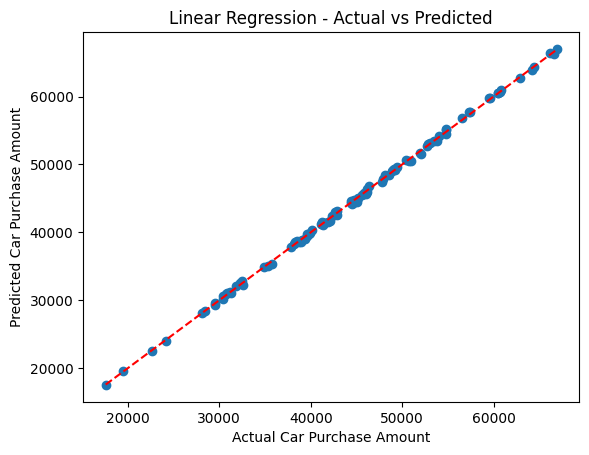

model name: Ridge Regression
--Mean squared error : 906166.4976807336
--Mean absolute error: 761.3760068204219
--Root Mean Squared error: 951.9277796559641
--R2 Score: 0.9921282823492227
-------------------


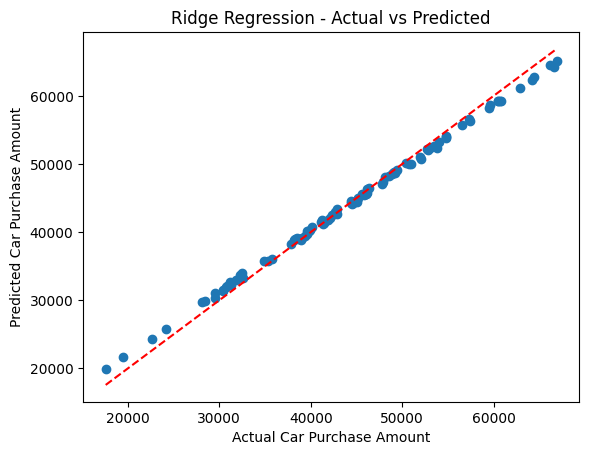

model name: Lasso Regression
--Mean squared error : 60346.06609327979
--Mean absolute error: 205.59894277871618
--Root Mean Squared error: 245.65436306583237
--R2 Score: 0.9994757837606696
-------------------


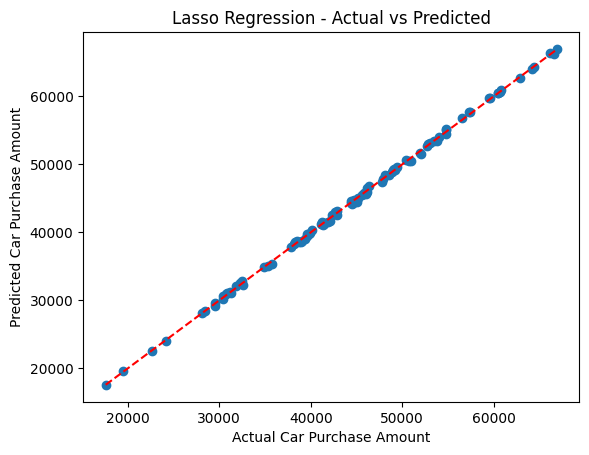

model name: Random Forest Regressor
--Mean squared error : 3676937.012338385
--Mean absolute error: 1362.9932323232322
--Root Mean Squared error: 1917.534096786387
--R2 Score: 0.9680590597258892
-------------------


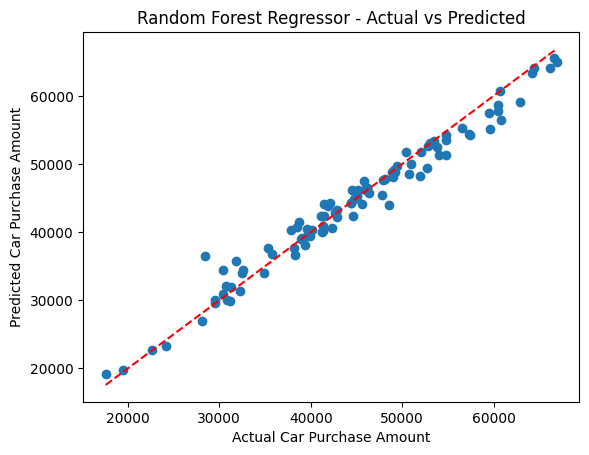

model name: Decision Tree Regressor
--Mean squared error : 13526679.323232323
--Mean absolute error: 2949.686868686869
--Root Mean Squared error: 3677.8634182405854
--R2 Score: 0.8824959864907657
-------------------


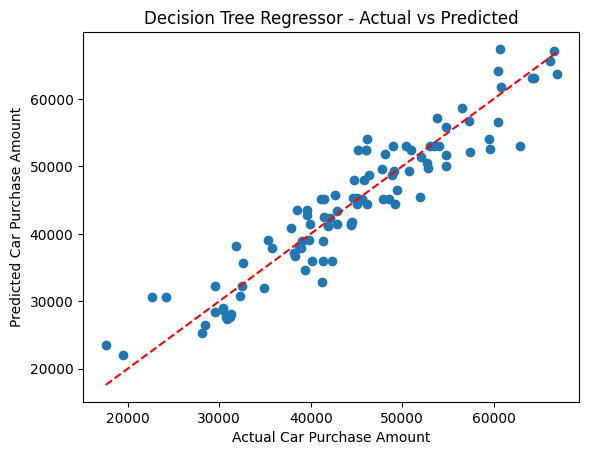

model name: Support Vector Machine
--Mean squared error : 115324690.93695128
--Mean absolute error: 8523.80842958225
--Root Mean Squared error: 10738.933417102058
--R2 Score: -0.001806409244100804
-------------------


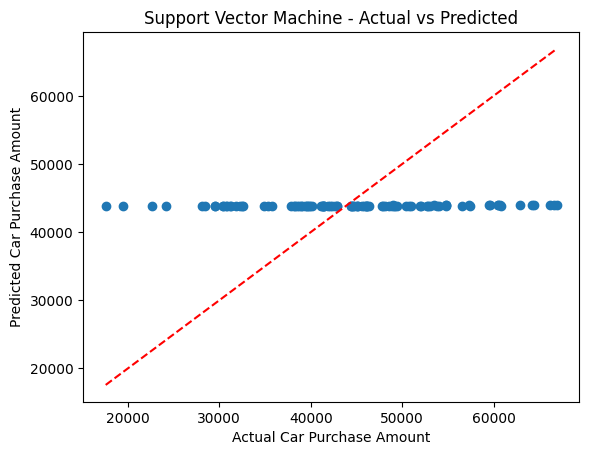

model name: XGB Regressor
--Mean squared error : 3496314.75
--Mean absolute error: 1505.5159912109375
--Root Mean Squared error: 1869.8435094948454
--R2 Score: 0.969628095626831
-------------------


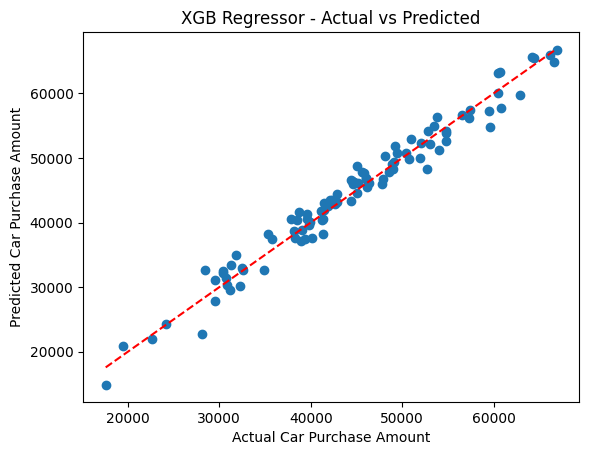

In [144]:
for name, model in models.items():
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test,y_pred)
    mae = mean_absolute_error(y_test,y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test,y_pred)

    print(f"model name: {name}")
    print(f"--Mean squared error : {mse}")
    print(f"--Mean absolute error: {mae}")
    print(f"--Root Mean Squared error: {rmse}")
    print(f"--R2 Score: {r2}")
    print("-------------------")


    # plot actual vs predicted value

    plt.scatter(y_test,y_pred)
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], '--', color='red')
    plt.xlabel('Actual Car Purchase Amount')
    plt.ylabel('Predicted Car Purchase Amount')
    plt.title(f'{name} - Actual vs Predicted')
    plt.show()